# Galaxy classification using convolutional neural networks
Loading the dataset:

TODO: CHANGE UMAP AND MATRIX TO USE TEST SET

In [1]:
#Import the dataset
import kagglehub
import os

os.environ['KAGGLE_USERNAME'] = "albinhallander"
os.environ['KAGGLE_KEY'] = "ce233f6d5335c1045328717347cee4a9"

In [2]:
import zipfile
import pandas as pd
import kagglehub
from glob import glob

#Fetch the dataset path from kaggle
path = kagglehub.competition_download('galaxy-zoo-the-galaxy-challenge')


for zip_file in glob(f"{path}/*.zip"):
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall(path)

#Load the probability labeled dataset
df_train = pd.read_csv(os.path.join(path, 'training_solutions_rev1.csv'))

train_folder = glob(f"{path}/**/100008.jpg", recursive=True)[0].replace('100008.jpg', '')
df_train['image_path'] = df_train['GalaxyID'].apply(lambda x: os.path.join(train_folder, f"{x}.jpg"))


print(f"Shape: {df_train.shape}")

df_train.columns

100%|██████████| 1.77G/1.77G [00:50<00:00, 37.6MB/s]

Extracting files...


Shape: (61578, 39)


Index(['GalaxyID', 'Class1.1', 'Class1.2', 'Class1.3', 'Class2.1', 'Class2.2',
       'Class3.1', 'Class3.2', 'Class4.1', 'Class4.2', 'Class5.1', 'Class5.2',
       'Class5.3', 'Class5.4', 'Class6.1', 'Class6.2', 'Class7.1', 'Class7.2',
       'Class7.3', 'Class8.1', 'Class8.2', 'Class8.3', 'Class8.4', 'Class8.5',
       'Class8.6', 'Class8.7', 'Class9.1', 'Class9.2', 'Class9.3', 'Class10.1',
       'Class10.2', 'Class10.3', 'Class11.1', 'Class11.2', 'Class11.3',
       'Class11.4', 'Class11.5', 'Class11.6', 'image_path'],
      dtype='object')

In [3]:
number_of_columns_per_class = [3, 2, 2, 2, 4, 2, 3, 7, 3, 3, 6]

col_start = 1

for n in range(11):
    l_num = n + 1
    col_stop = col_start + number_of_columns_per_class[n]


    current_question_cols = df_train.columns[col_start:col_stop]

    col_to_index = {col_name: idx for idx, col_name in enumerate(current_question_cols)}

    df_train[f'label_{l_num}'] = df_train[current_question_cols].idxmax(axis=1).map(col_to_index)

    col_start = col_stop

df =  df_train.drop(columns=df_train.columns[0:38])

df.columns

Index(['image_path', 'label_1', 'label_2', 'label_3', 'label_4', 'label_5',
       'label_6', 'label_7', 'label_8', 'label_9', 'label_10', 'label_11'],
      dtype='object')

Examining the dataset including calculation of class distribution per label type to determine how well the dataset is balanced and sampling images from each class type to better understand the data.

In [4]:
from matplotlib.image import imread
img_size = imread(df['image_path'].iloc[0]).shape
print(f"Image size: {img_size}")

Image size: (424, 424, 3)


In [5]:
# Loopa igenom alla 11 labels och skriv ut fördelningen
for i in range(1, 12):
    print(f"\n=========================================")
    print(f"Fördelning för label {i}")
    print(f"=========================================")

    # Beräkna antal och procent
    counts = df[f'label_{i}'].value_counts().sort_index()
    percentages = df[f'label_{i}'].value_counts(normalize=True).sort_index() * 100


    distribution_df = pd.DataFrame({
        'Antal galaxer': counts,
        'Andel (%)': percentages
    })
    print(distribution_df.round(2))



Fördelning för label 1
         Antal galaxer  Andel (%)
label_1                          
0                26693      43.35
1                34826      56.56
2                   59       0.10

Fördelning för label 2
         Antal galaxer  Andel (%)
label_2                          
0                 9727       15.8
1                51851       84.2

Fördelning för label 3
         Antal galaxer  Andel (%)
label_3                          
0                12508      20.31
1                49070      79.69

Fördelning för label 4
         Antal galaxer  Andel (%)
label_4                          
0                25113      40.78
1                36465      59.22

Fördelning för label 5
         Antal galaxer  Andel (%)
label_5                          
0                 8069      13.10
1                23169      37.63
2                27457      44.59
3                 2883       4.68

Fördelning för label 6
         Antal galaxer  Andel (%)
label_6                          
0     

Example galaxy for each class in label type 1


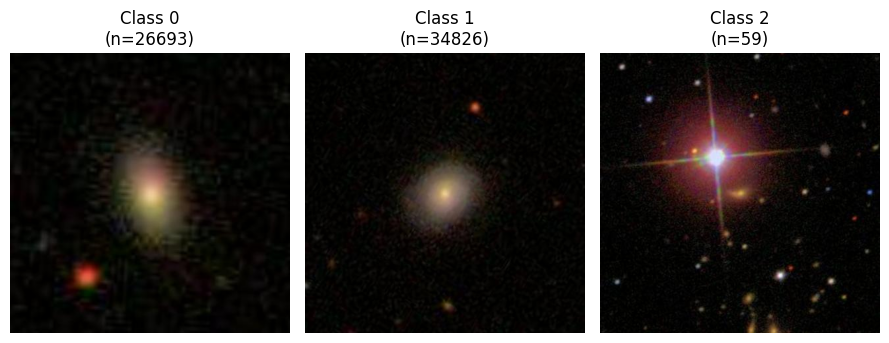

Example galaxy for each class in label type 2


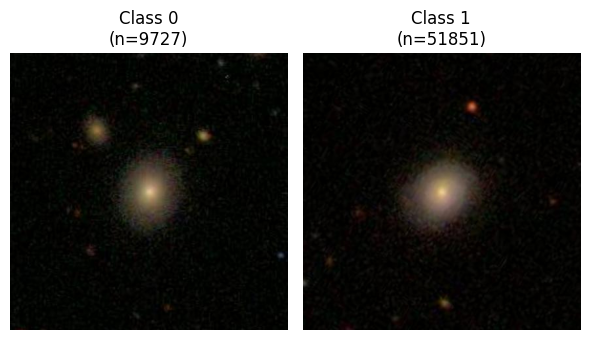

Example galaxy for each class in label type 3


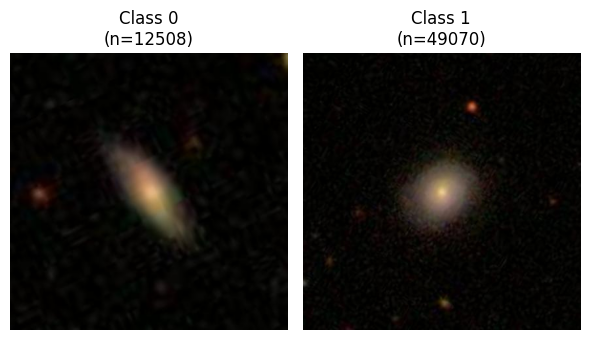

Example galaxy for each class in label type 4


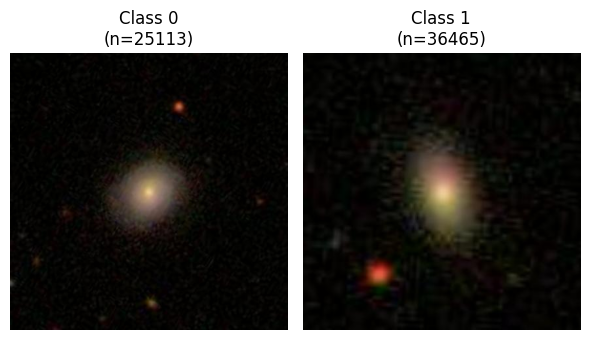

Example galaxy for each class in label type 5


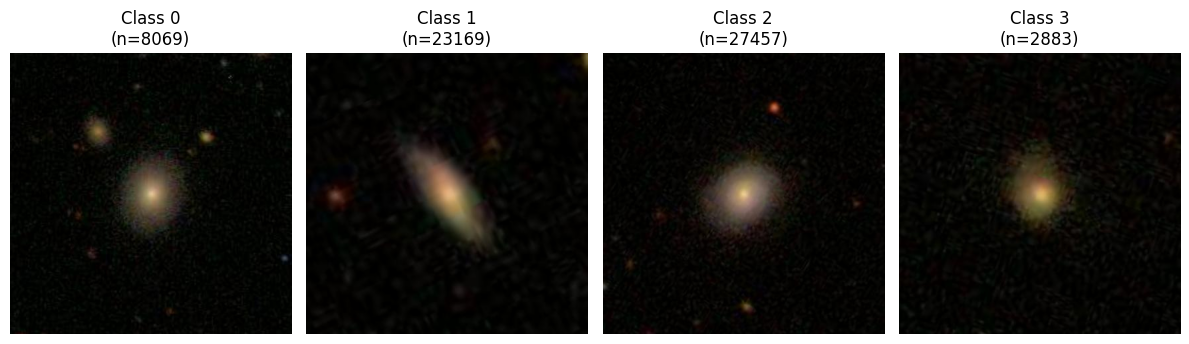

Example galaxy for each class in label type 6


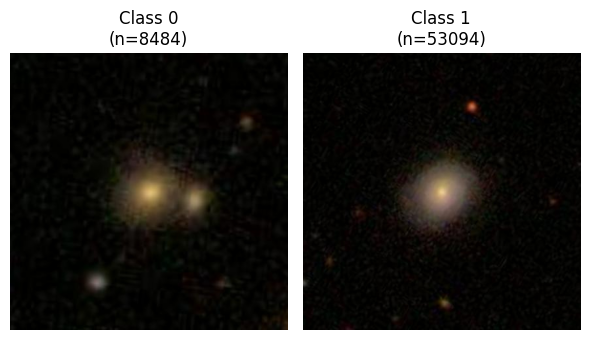

Example galaxy for each class in label type 7


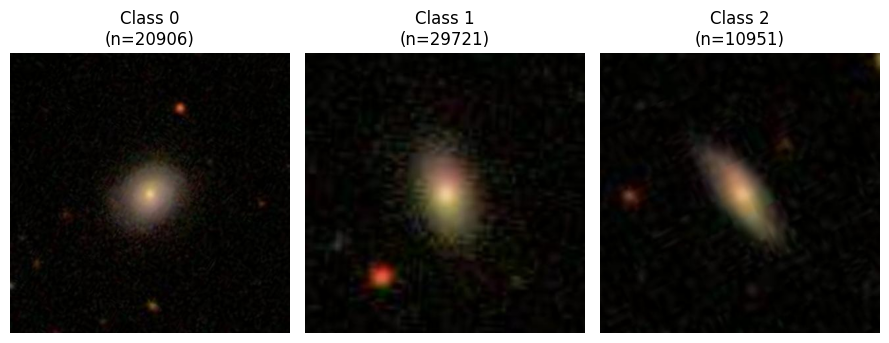

Example galaxy for each class in label type 8


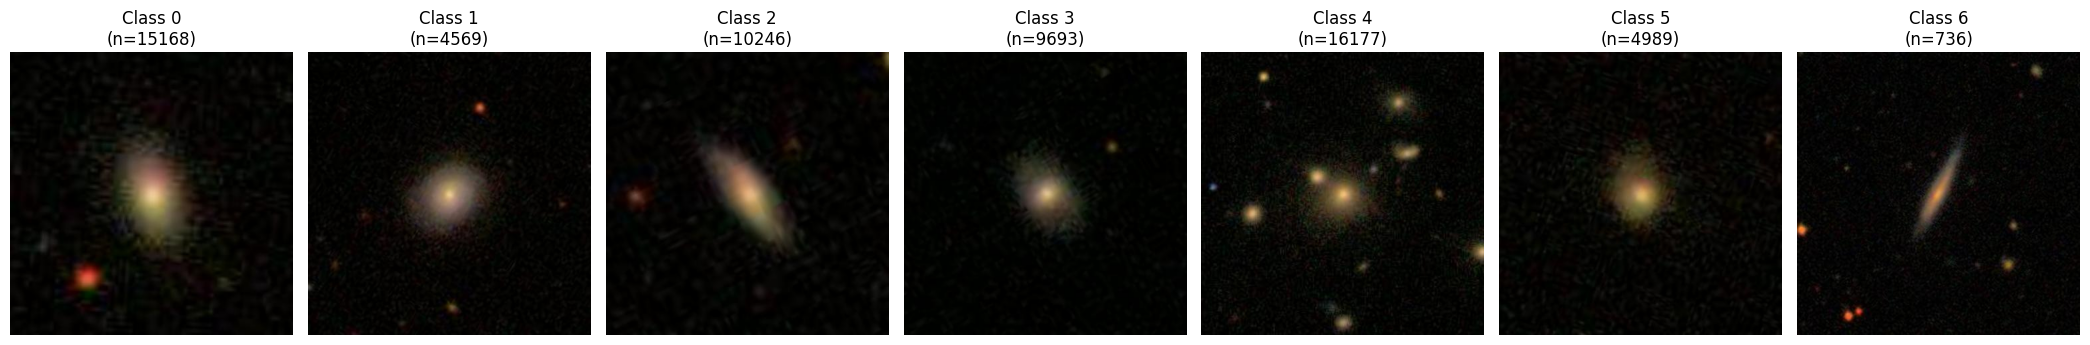

Example galaxy for each class in label type 9


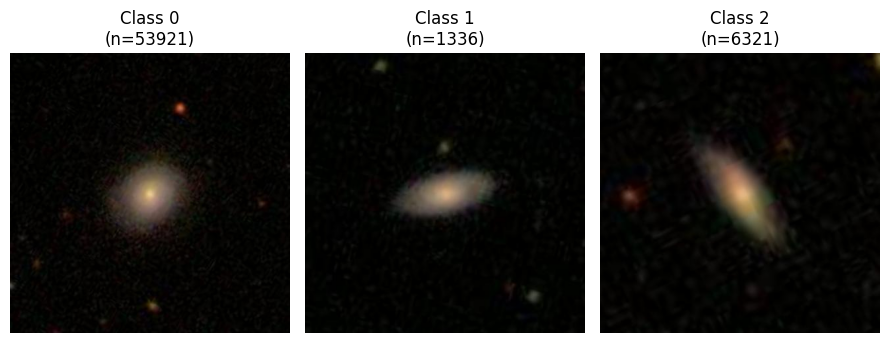

Example galaxy for each class in label type 10


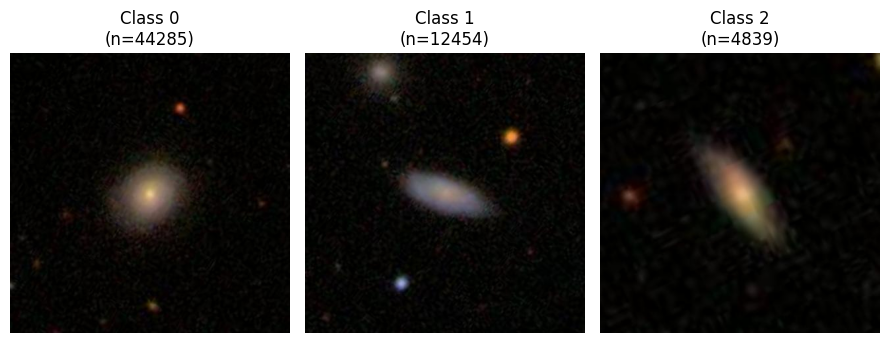

Example galaxy for each class in label type 11


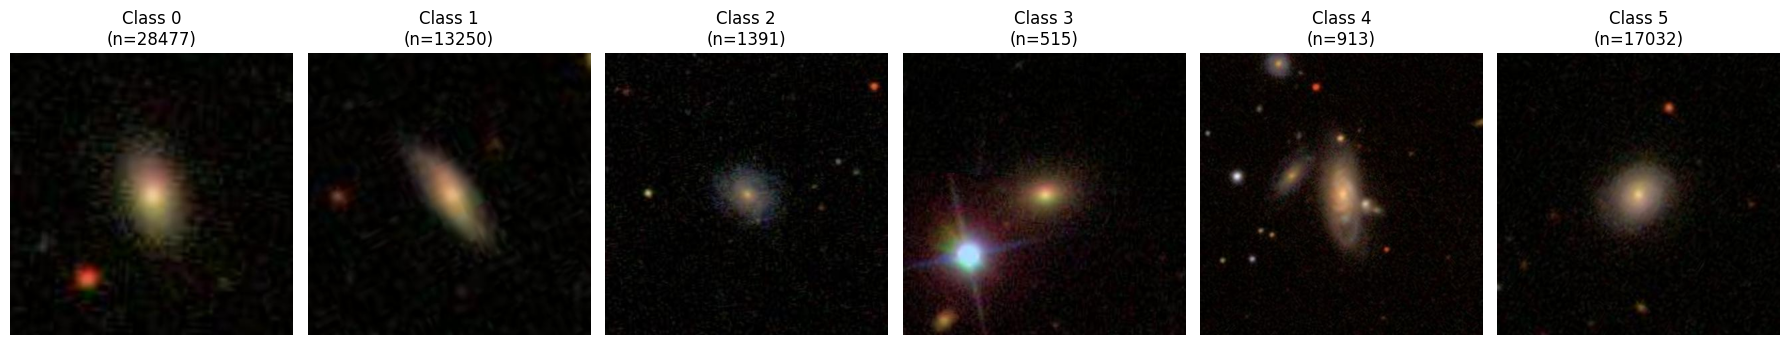

In [6]:
import matplotlib.pyplot as plt
from matplotlib.image import imread

number_of_columns_per_class = [3, 2, 2, 2, 4, 2, 3, 7, 3, 3, 6]

for i in range(1, 12):
    n_classes = number_of_columns_per_class[i - 1]
    label_col = f'label_{i}'

    fig, axes = plt.subplots(1, n_classes, figsize=(3 * n_classes, 3.5))
    if n_classes == 1:
        axes = [axes]

    print(f'Example galaxy for each class in label type {i}')

    for class_idx in range(n_classes):
        subset = df[df[label_col] == class_idx]

        ax = axes[class_idx]
        if len(subset) > 0:
            img_path = subset.iloc[0]['image_path']
            img = imread(img_path)
            ax.imshow(img)
            ax.set_title(f'Class {class_idx}\n(n={len(subset)})')
        else:
            ax.set_title(f'Class {class_idx}\n(no samples)')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# LeNet 5

Create a dataloader:

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

class GalaxyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_cols = [f'label_{i}' for i in range(1, 12)]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        labels = torch.tensor([row[c] for c in self.label_cols], dtype=torch.long)
        return img, labels

# Training: augment (flips + rotation) at full res, then downscale to 32x32 grayscale
train_transform = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.Resize(32),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# Eval: no augmentation
eval_transform = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.Resize(32),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

full_train = GalaxyDataset(df, transform=train_transform)
full_eval  = GalaxyDataset(df, transform=eval_transform)

n_total = len(full_train)
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)
n_test  = n_total - n_train - n_val

g = torch.Generator().manual_seed(42)
train_set, _, _ = random_split(full_train, [n_train, n_val, n_test], generator=g)
g = torch.Generator().manual_seed(42)        # same seed → identical split, no leakage
_, val_set, test_set = random_split(full_eval, [n_train, n_val, n_test], generator=g)

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

imgs, labels = next(iter(train_loader))
print(f"Batch images: {imgs.shape}")
print(f"Batch labels: {labels.shape}")
print(f"Train / Val / Test: {n_train} / {n_val} / {n_test}")


Batch images: torch.Size([128, 1, 32, 32])
Batch labels: torch.Size([128, 11])
Train / Val / Test: 49262 / 6157 / 6159


Build train and evaluate the LeNet5:

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

num_classes_per_head = [3, 2, 2, 2, 4, 2, 3, 7, 3, 3, 6]

class MultiHeadLeNet5(nn.Module):
    def __init__(self, num_classes_per_head):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.trunk = nn.Sequential(
            nn.Flatten(),
            nn.Linear(400, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
        )
        self.heads = nn.ModuleList([nn.Linear(84, n) for n in num_classes_per_head])

    def forward(self, x):
        x = self.features(x)
        x = self.trunk(x)
        return [head(x) for head in self.heads]

model = MultiHeadLeNet5(num_classes_per_head).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15
history = {'train_loss': [], 'val_loss': [], 'val_acc_mean': []}

for epoch in range(num_epochs):
    #train
    model.train()
    train_loss, train_total = 0.0, 0
    train_correct = [0] * 11
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [train]"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = sum(criterion(outputs[i], labels[:, i]) for i in range(11))
        loss.backward()
        optimizer.step()

        bs = imgs.size(0)
        train_loss  += loss.item() * bs
        train_total += bs
        for i in range(11):
            train_correct[i] += (outputs[i].argmax(1) == labels[:, i]).sum().item()

    #validation
    model.eval()
    val_loss, val_total = 0.0, 0
    val_correct = [0] * 11
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = sum(criterion(outputs[i], labels[:, i]) for i in range(11))

            bs = imgs.size(0)
            val_loss  += loss.item() * bs
            val_total += bs
            for i in range(11):
                val_correct[i] += (outputs[i].argmax(1) == labels[:, i]).sum().item()

    train_acc = [c / train_total for c in train_correct]
    val_acc   = [c / val_total   for c in val_correct]

    history['train_loss'].append(train_loss / train_total)
    history['val_loss'].append(val_loss / val_total)
    history['val_acc_mean'].append(sum(val_acc) / 11)

    print(f"\nEpoch {epoch+1}: train_loss={train_loss/train_total:.4f}  val_loss={val_loss/val_total:.4f}")
    print(f"  Val acc per head : {[f'{a:.3f}' for a in val_acc]}")
    print(f"  Mean val acc     : {sum(val_acc)/11:.4f}")

Using device: cuda


Epoch 1/15 [train]: 100%|██████████| 385/385 [00:47<00:00,  8.05it/s]



Epoch 1: train_loss=8.8374  val_loss=8.1665
  Val acc per head : ['0.711', '0.889', '0.801', '0.621', '0.558', '0.857', '0.635', '0.301', '0.880', '0.713', '0.510']
  Mean val acc     : 0.6796


Epoch 2/15 [train]: 100%|██████████| 385/385 [00:49<00:00,  7.73it/s]



Epoch 2: train_loss=7.8543  val_loss=7.8203
  Val acc per head : ['0.759', '0.899', '0.804', '0.646', '0.575', '0.857', '0.675', '0.327', '0.886', '0.713', '0.525']
  Mean val acc     : 0.6969


...


Epoch 13: train_loss=7.0510  val_loss=7.0284
  Val acc per head : ['0.810', '0.907', '0.810', '0.670', '0.623', '0.876', '0.829', '0.356', '0.898', '0.722', '0.567']
  Mean val acc     : 0.7334


Epoch 14/15 [train]: 100%|██████████| 385/385 [00:49<00:00,  7.84it/s]



Epoch 14: train_loss=7.0120  val_loss=7.0203
  Val acc per head : ['0.800', '0.909', '0.807', '0.668', '0.624', '0.875', '0.826', '0.365', '0.898', '0.725', '0.568']
  Mean val acc     : 0.7331


Epoch 15/15 [train]: 100%|██████████| 385/385 [00:49<00:00,  7.78it/s]



Epoch 15: train_loss=7.0023  val_loss=7.0075
  Val acc per head : ['0.807', '0.910', '0.811', '0.668', '0.623', '0.876', '0.830', '0.366', '0.897', '0.726', '0.574']
  Mean val acc     : 0.7353


Evaluate the model

Features: (6159, 84), Labels: (6159, 11)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


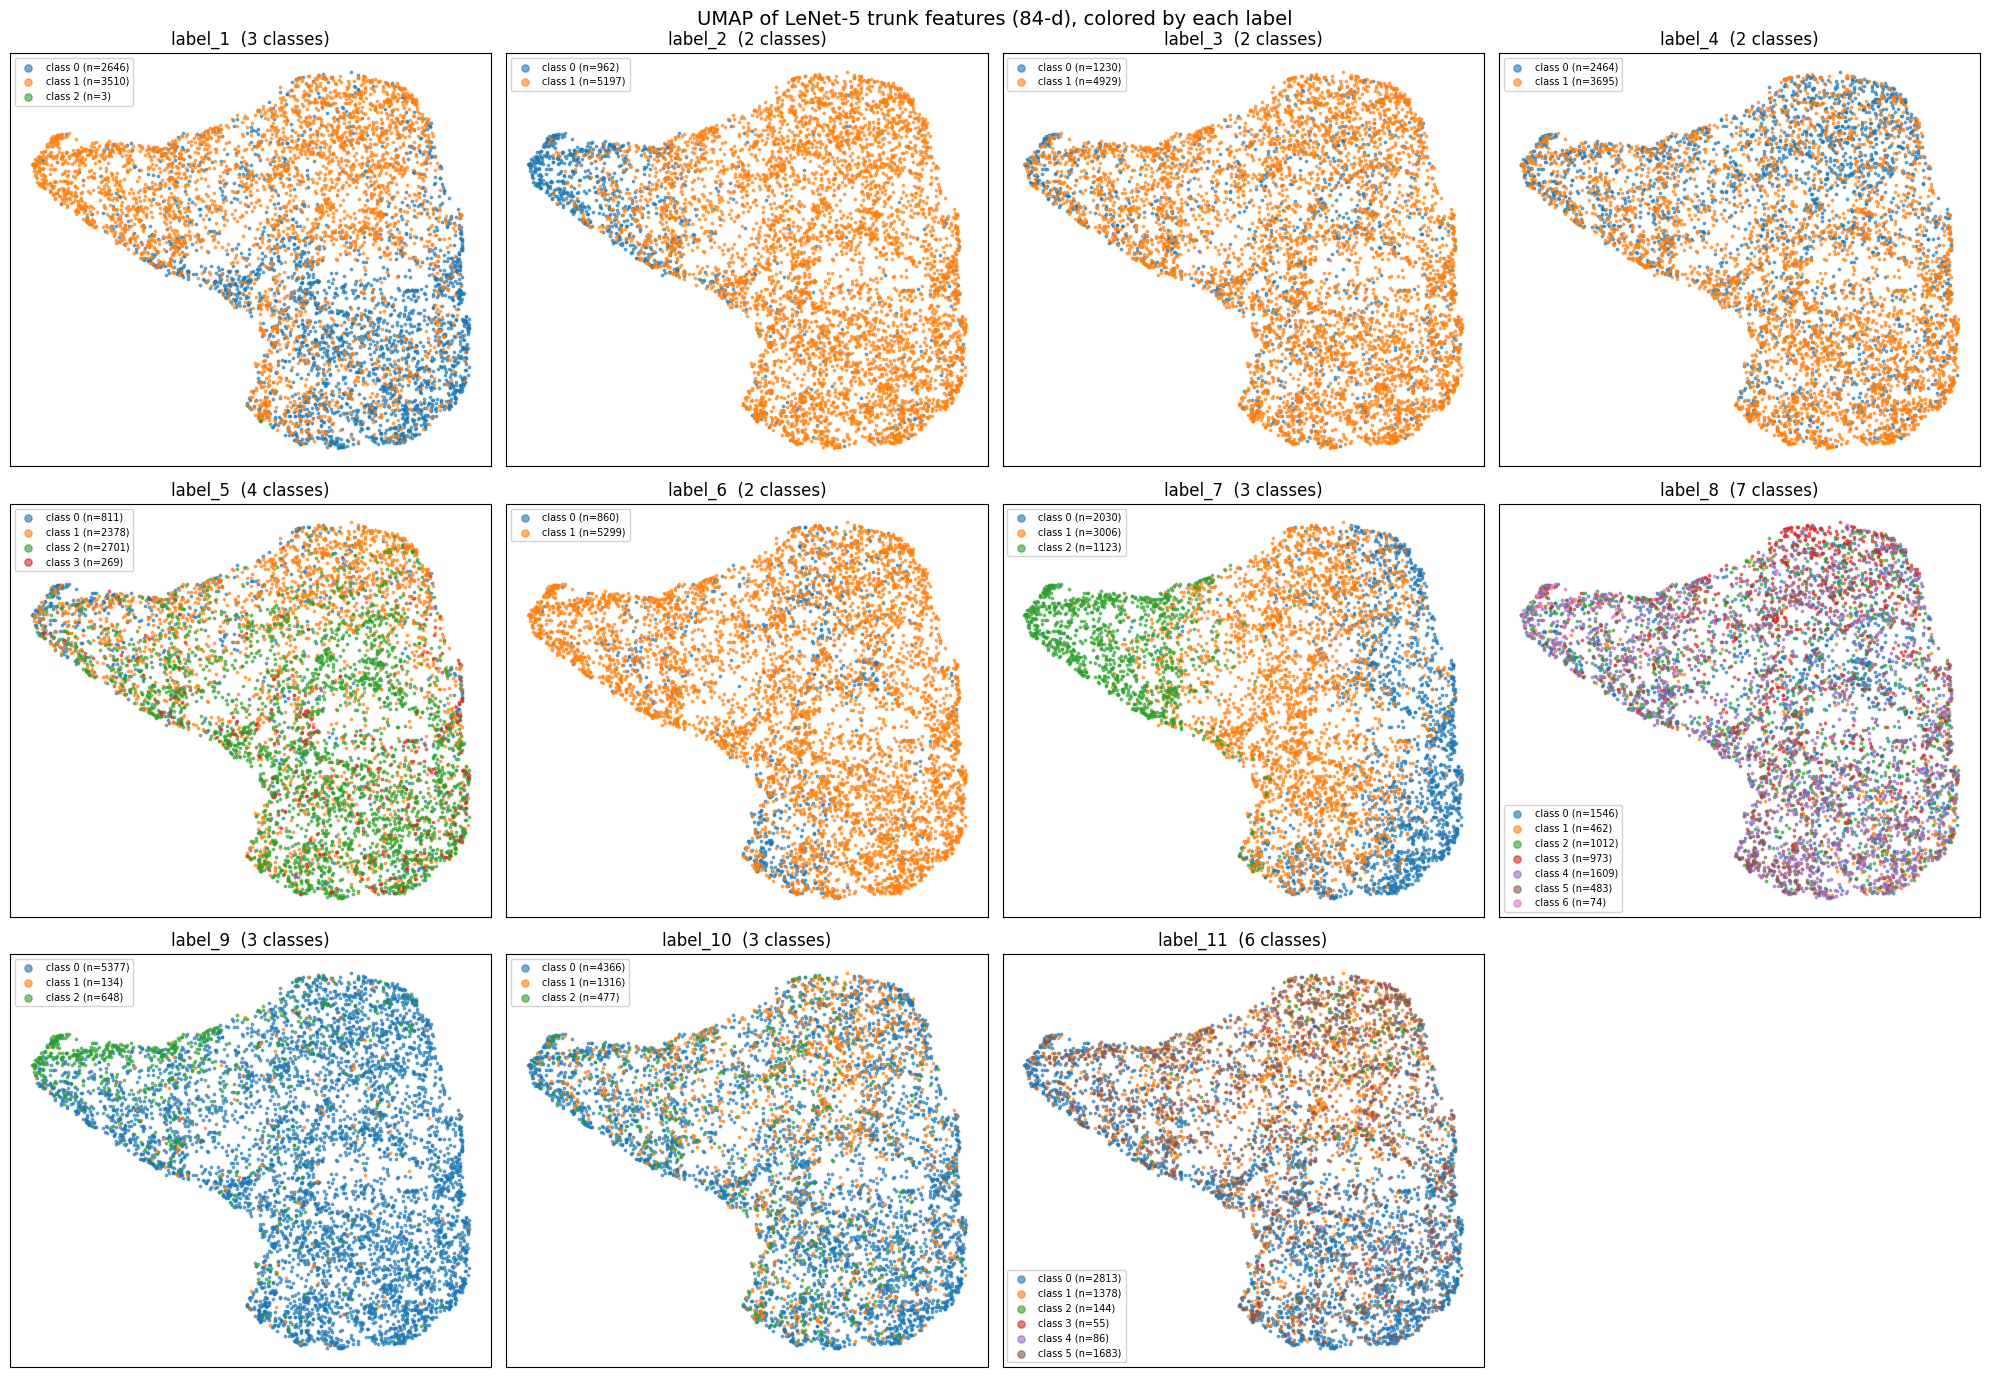

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import umap


model.eval()
features, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        feats = model.trunk(model.features(imgs))
        features.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())

features   = np.concatenate(features,   axis=0)
all_labels = np.concatenate(all_labels, axis=0)
print(f"Features: {features.shape}, Labels: {all_labels.shape}")


reducer   = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(features)

palette = plt.get_cmap('tab10').colors

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i in range(11):
    ax = axes[i]
    n_classes = num_classes_per_head[i]

    for c in range(n_classes):
        mask = all_labels[:, i] == c
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            color=palette[c], s=3, alpha=0.6,
            label=f'class {c} (n={mask.sum()})',
        )

    ax.set_title(f'label_{i+1}  ({n_classes} classes)')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc='best', fontsize=7, markerscale=3, framealpha=0.85)

axes[11].axis('off')
fig.suptitle('UMAP of LeNet-5 trunk features (84-d), colored by each label', fontsize=14)
plt.tight_layout()
plt.show()

label_1    acc = 0.799
label_2    acc = 0.912
label_3    acc = 0.808
label_4    acc = 0.662
label_5    acc = 0.627
label_6    acc = 0.874
label_7    acc = 0.833
label_8    acc = 0.370
label_9    acc = 0.897
label_10   acc = 0.718
label_11   acc = 0.572

Mean acc = 0.734


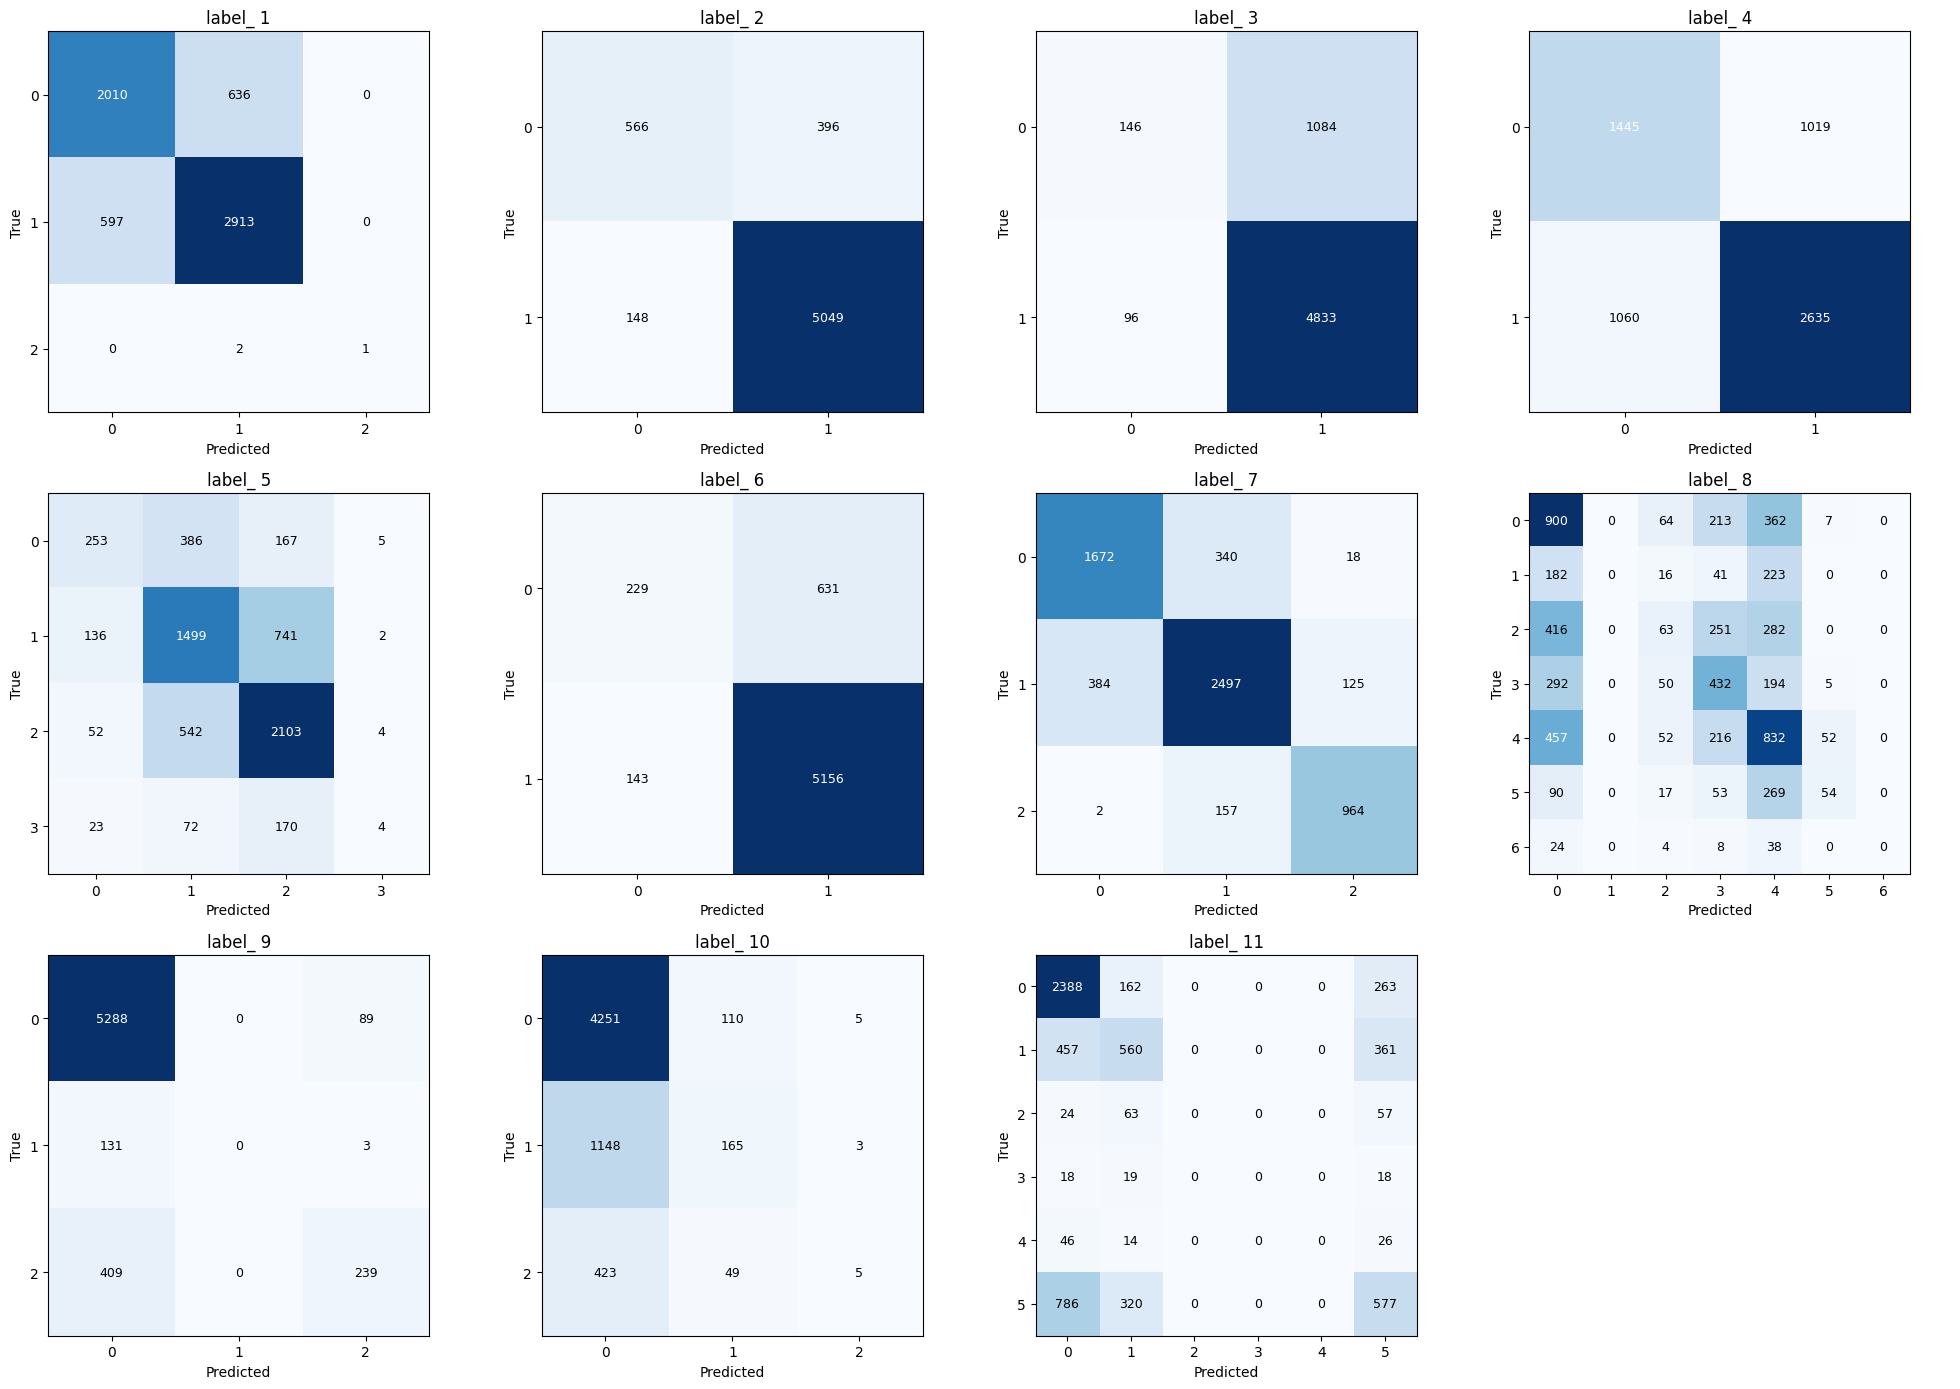

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


model.eval()
all_preds = [[] for _ in range(11)]
all_trues = [[] for _ in range(11)]

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        for i in range(11):
            all_preds[i].append(outputs[i].argmax(1).cpu().numpy())
            all_trues[i].append(labels[:, i].numpy())

all_preds = [np.concatenate(p) for p in all_preds]
all_trues = [np.concatenate(t) for t in all_trues]


for i in range(11):
    acc = (all_preds[i] == all_trues[i]).mean()
    print(f"label_{i+1:<3}  acc = {acc:.3f}")

mean_acc = np.mean([(all_preds[i] == all_trues[i]).mean() for i in range(11)])
print(f"\nMean acc = {mean_acc:.3f}")


fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i in range(11):
    ax = axes[i]
    n_classes = num_classes_per_head[i]
    cm = confusion_matrix(all_trues[i], all_preds[i], labels=list(range(n_classes)))

    ax.imshow(cm, cmap='Blues')
    ax.set_title(f'label_ {i+1}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))

    for r in range(n_classes):
        for c in range(n_classes):
            ax.text(c, r, cm[r, c], ha='center', va='center', fontsize=9,
                    color='white' if cm[r, c] > cm.max() / 2 else 'black')

axes[11].axis('off')
plt.tight_layout()
plt.show()

# ConvNeXt V2

Create a dataloader

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

class GalaxyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_cols = [f'label_{i}' for i in range(1, 12)]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        labels = torch.tensor([row[c] for c in self.label_cols], dtype=torch.long)
        return img, labels

# Training: random rotation + flips (galaxies are orientation-invariant)
train_transform = transforms.Compose([
    transforms.CenterCrop(384),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
])

# Eval: no augmentation
eval_transform = transforms.Compose([
    transforms.CenterCrop(384),
    transforms.ToTensor(),
])

full_train = GalaxyDataset(df, transform=train_transform)
full_eval  = GalaxyDataset(df, transform=eval_transform)

n_total = len(full_train)
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)
n_test  = n_total - n_train - n_val

g = torch.Generator().manual_seed(42)
train_set, _, _ = random_split(full_train, [n_train, n_val, n_test], generator=g)
g = torch.Generator().manual_seed(42)        # same seed → identical split, no leakage
_, val_set, test_set = random_split(full_eval, [n_train, n_val, n_test], generator=g)

batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Sanity + confirm augmentation is live
imgs, labels = next(iter(train_loader))
print(f"Batch images: {imgs.shape}")
print(f"Batch labels: {labels.shape}")
print(f"Train / Val / Test: {n_train} / {n_val} / {n_test}")
a, _ = train_set[0]; b, _ = train_set[0]
print("Augmentation active:", not torch.equal(a, b))   # want True

Batch images: torch.Size([64, 3, 384, 384])
Batch labels: torch.Size([64, 11])
Train / Val / Test: 49262 / 6157 / 6159
Augmentation active: True


Setup and finetune the model

In [12]:
import torch
import torch.nn as nn
from transformers import ConvNextV2Model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

num_classes_per_head = [3, 2, 2, 2, 4, 2, 3, 7, 3, 3, 6]

class MultiHeadConvNeXtV2(nn.Module):

    def __init__(self,
                 num_classes_per_head,
                 model_name='facebook/convnextv2-base-22k-384'):
        super().__init__()
        # ConvNextV2Model
        self.backbone = ConvNextV2Model.from_pretrained(model_name)
        feat_dim = self.backbone.config.hidden_sizes[-1]
        self.heads = nn.ModuleList([nn.Linear(feat_dim, n) for n in num_classes_per_head])

    def forward(self, x):
        outputs = self.backbone(pixel_values=x)
        feats   = outputs.pooler_output
        return [head(feats) for head in self.heads]

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

model = MultiHeadConvNeXtV2(num_classes_per_head).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params         : {total:,}")
print(f"Trainable params     : {trainable:,}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/355M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/378 [00:00<?, ?it/s]

ConvNextV2Model LOAD REPORT from: facebook/convnextv2-base-22k-384
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params         : 87,730,725
Trainable params     : 87,730,725


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-5},
    {'params': model.heads.parameters(),    'lr': 1e-4},
], weight_decay=0.05)

num_epochs = 15
history = {'train_loss': [], 'val_loss': [], 'val_acc_mean': []}

def run_epoch(loader, label, train):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    correct = [0] * 11
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, desc=label, leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                outputs = model(imgs)
                loss = sum(criterion(outputs[i], labels[:, i]) for i in range(11))
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            bs = imgs.size(0)
            total_loss += loss.item() * bs
            n += bs
            for i in range(11):
                correct[i] += (outputs[i].argmax(1) == labels[:, i]).sum().item()
    return total_loss / n, [c / n for c in correct]

for epoch in range(1, num_epochs + 1):
    tr_loss, _      = run_epoch(train_loader, f"Epoch {epoch} [train]", train=True)
    val_loss, val_a = run_epoch(val_loader,   f"Epoch {epoch} [val]",   train=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_acc_mean'].append(sum(val_a) / 11)

    print(f"\nEpoch {epoch}: train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}")
    print(f"  Val acc per head : {[f'{a:.3f}' for a in val_a]}")
    print(f"  Mean val acc     : {sum(val_a)/11:.4f}")


Epoch 1: train_loss=6.3810  val_loss=5.8094
  Val acc per head : ['0.866', '0.931', '0.850', '0.750', '0.669', '0.926', '0.879', '0.487', '0.905', '0.771', '0.660']
  Mean val acc     : 0.7904



Epoch 2: train_loss=5.6958  val_loss=5.5994
  Val acc per head : ['0.872', '0.934', '0.856', '0.760', '0.681', '0.936', '0.884', '0.509', '0.904', '0.779', '0.669']
  Mean val acc     : 0.7986



Epoch 3: train_loss=5.5347  val_loss=5.5502
  Val acc per head : ['0.875', '0.932', '0.860', '0.767', '0.674', '0.937', '0.891', '0.512', '0.906', '0.780', '0.679']
  Mean val acc     : 0.8012



Epoch 4: train_loss=5.4391  val_loss=5.4738
  Val acc per head : ['0.871', '0.933', '0.863', '0.772', '0.683', '0.938', '0.882', '0.522', '0.905', '0.782', '0.676']
  Mean val acc     : 0.8025



Epoch 5: train_loss=5.3578  val_loss=5.4318
  Val acc per head : ['0.874', '0.933', '0.863', '0.769', '0.687', '0.940', '0.884', '0.525', '0.906', '0.781', '0.687']
  Mean val acc     : 0.8044


...


Epoch 11: train_loss=5.0401  val_loss=5.3704
  Val acc per head : ['0.875', '0.933', '0.872', '0.774', '0.689', '0.941', '0.893', '0.533', '0.905', '0.783', '0.682']
  Mean val acc     : 0.8075



Epoch 12: train_loss=4.9816  val_loss=5.3525
  Val acc per head : ['0.876', '0.933', '0.869', '0.772', '0.691', '0.942', '0.898', '0.526', '0.905', '0.783', '0.682']
  Mean val acc     : 0.8070



Epoch 13: train_loss=4.9337  val_loss=5.3837
  Val acc per head : ['0.880', '0.932', '0.869', '0.778', '0.690', '0.937', '0.892', '0.530', '0.906', '0.777', '0.684']
  Mean val acc     : 0.8069



Epoch 14: train_loss=4.8789  val_loss=5.4076
  Val acc per head : ['0.875', '0.931', '0.866', '0.778', '0.693', '0.940', '0.891', '0.530', '0.906', '0.784', '0.685']
  Mean val acc     : 0.8073



Epoch 15: train_loss=4.8138  val_loss=5.4079
  Val acc per head : ['0.878', '0.934', '0.869', '0.776', '0.689', '0.940', '0.892', '0.530', '0.907', '0.778', '0.685']
  Mean val acc     : 0.8071


Features: (6159, 1024), Labels: (6159, 11)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


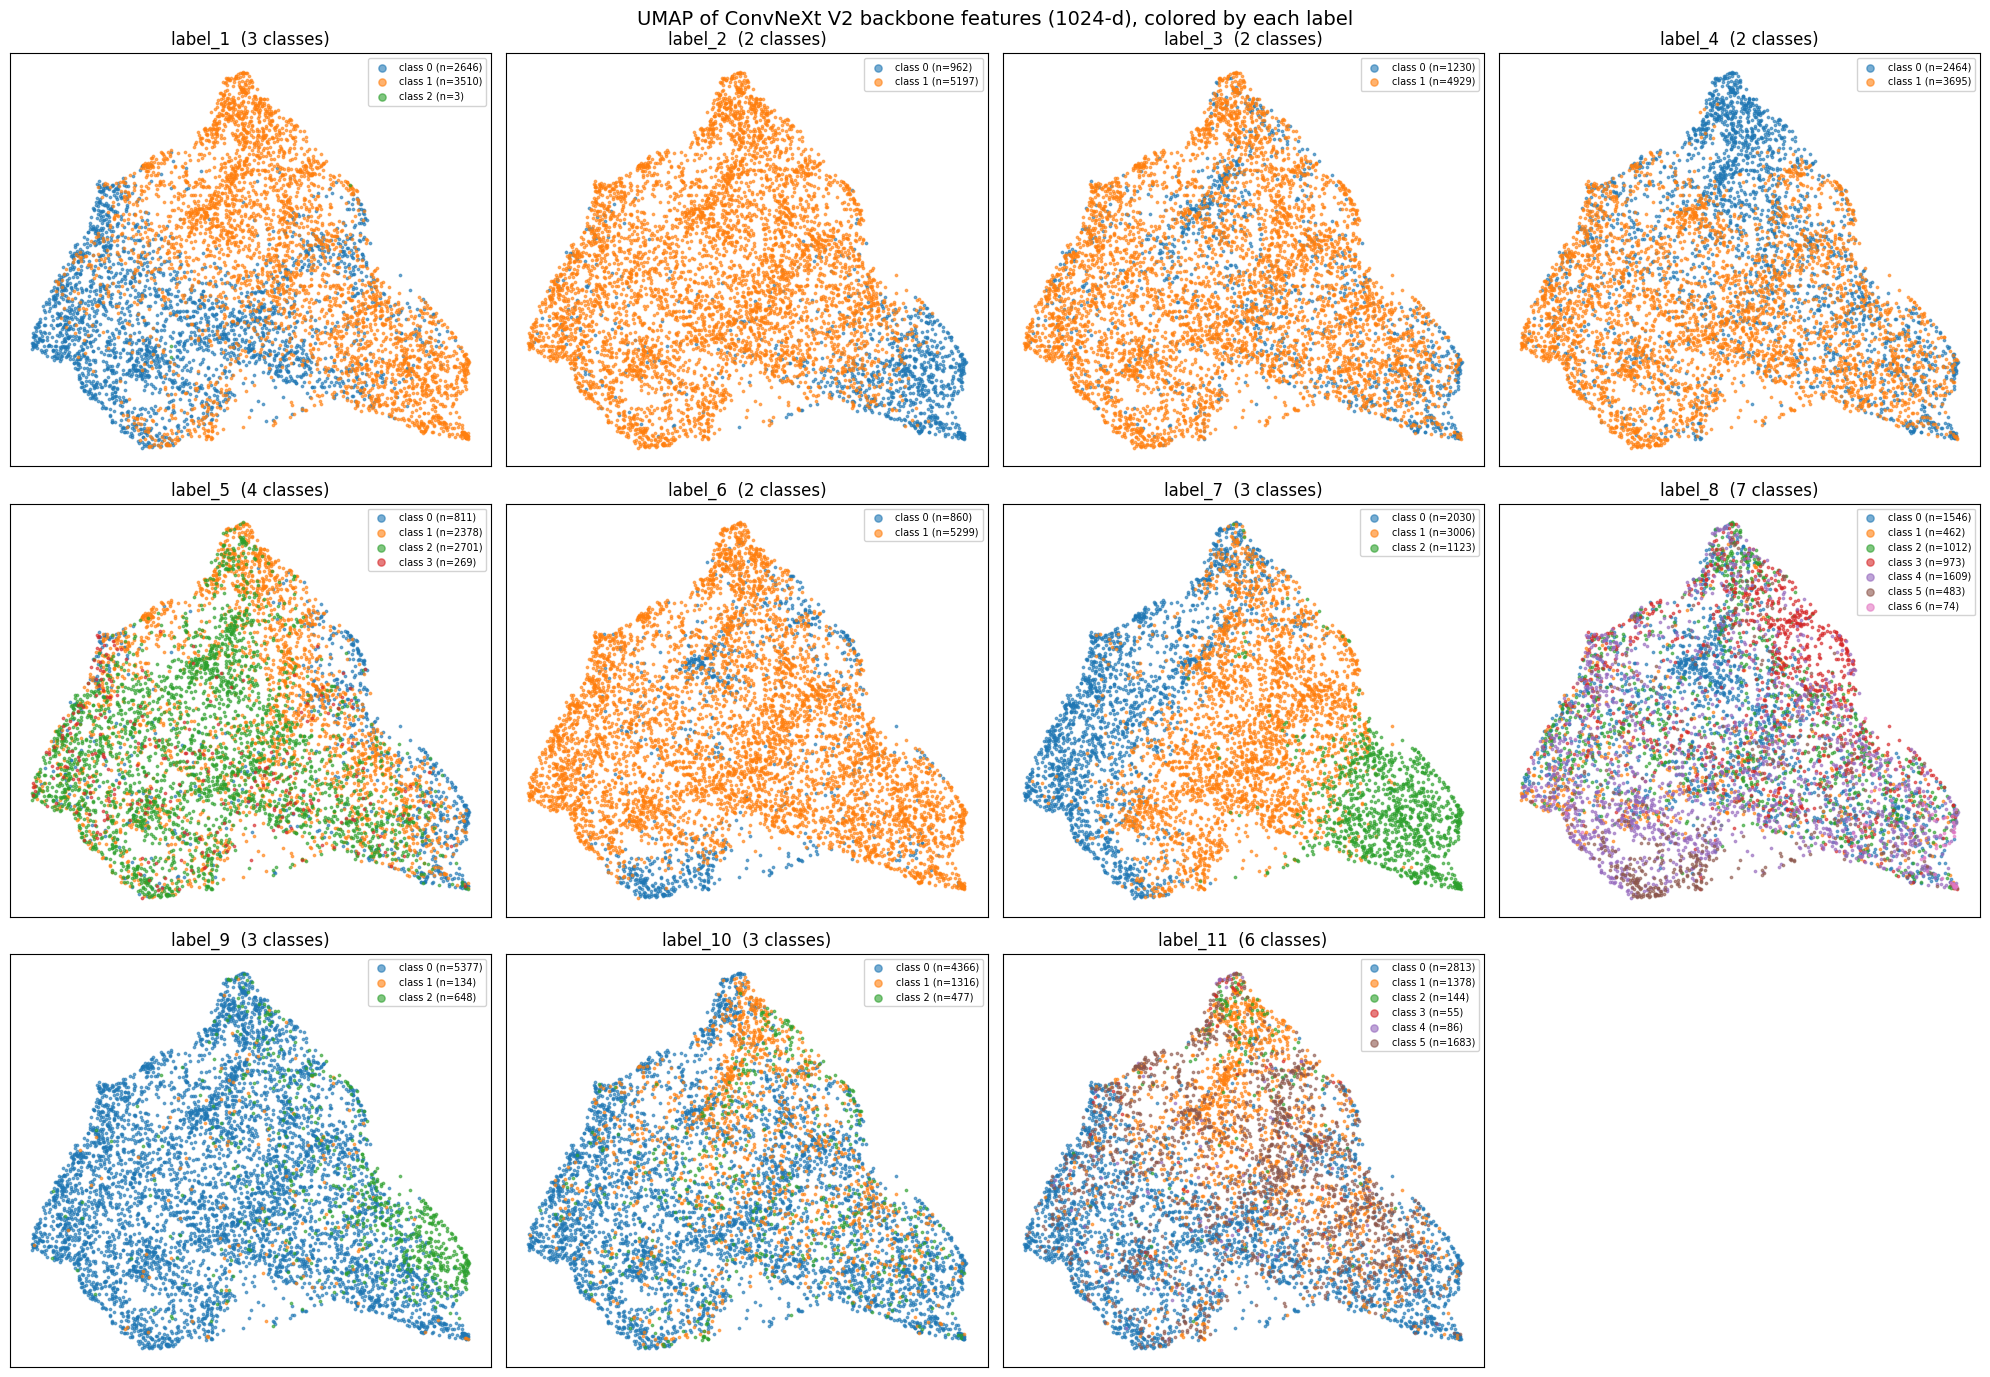

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import umap

model.eval()
features, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            outputs = model.backbone(pixel_values=imgs)
        feats = outputs.pooler_output.float()        # [B, 1024]
        features.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())

features   = np.concatenate(features,   axis=0)     # [N, 1024]
all_labels = np.concatenate(all_labels, axis=0)     # [N, 11]
print(f"Features: {features.shape}, Labels: {all_labels.shape}")

reducer   = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(features)

palette = plt.get_cmap('tab10').colors

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i in range(11):
    ax = axes[i]
    n_classes = num_classes_per_head[i]

    for c in range(n_classes):
        mask = all_labels[:, i] == c
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            color=palette[c], s=3, alpha=0.6,
            label=f'class {c} (n={mask.sum()})',
        )

    ax.set_title(f'label_{i+1}  ({n_classes} classes)')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc='upper right', fontsize=7, markerscale=3, framealpha=0.85)

axes[11].axis('off')
fig.suptitle('UMAP of ConvNeXt V2 backbone features (1024-d), colored by each label', fontsize=14)
plt.tight_layout()
plt.show()

label_1    acc = 0.880
label_2    acc = 0.932
label_3    acc = 0.858
label_4    acc = 0.780
label_5    acc = 0.680
label_6    acc = 0.940
label_7    acc = 0.893
label_8    acc = 0.537
label_9    acc = 0.908
label_10   acc = 0.769
label_11   acc = 0.684

Mean acc = 0.806


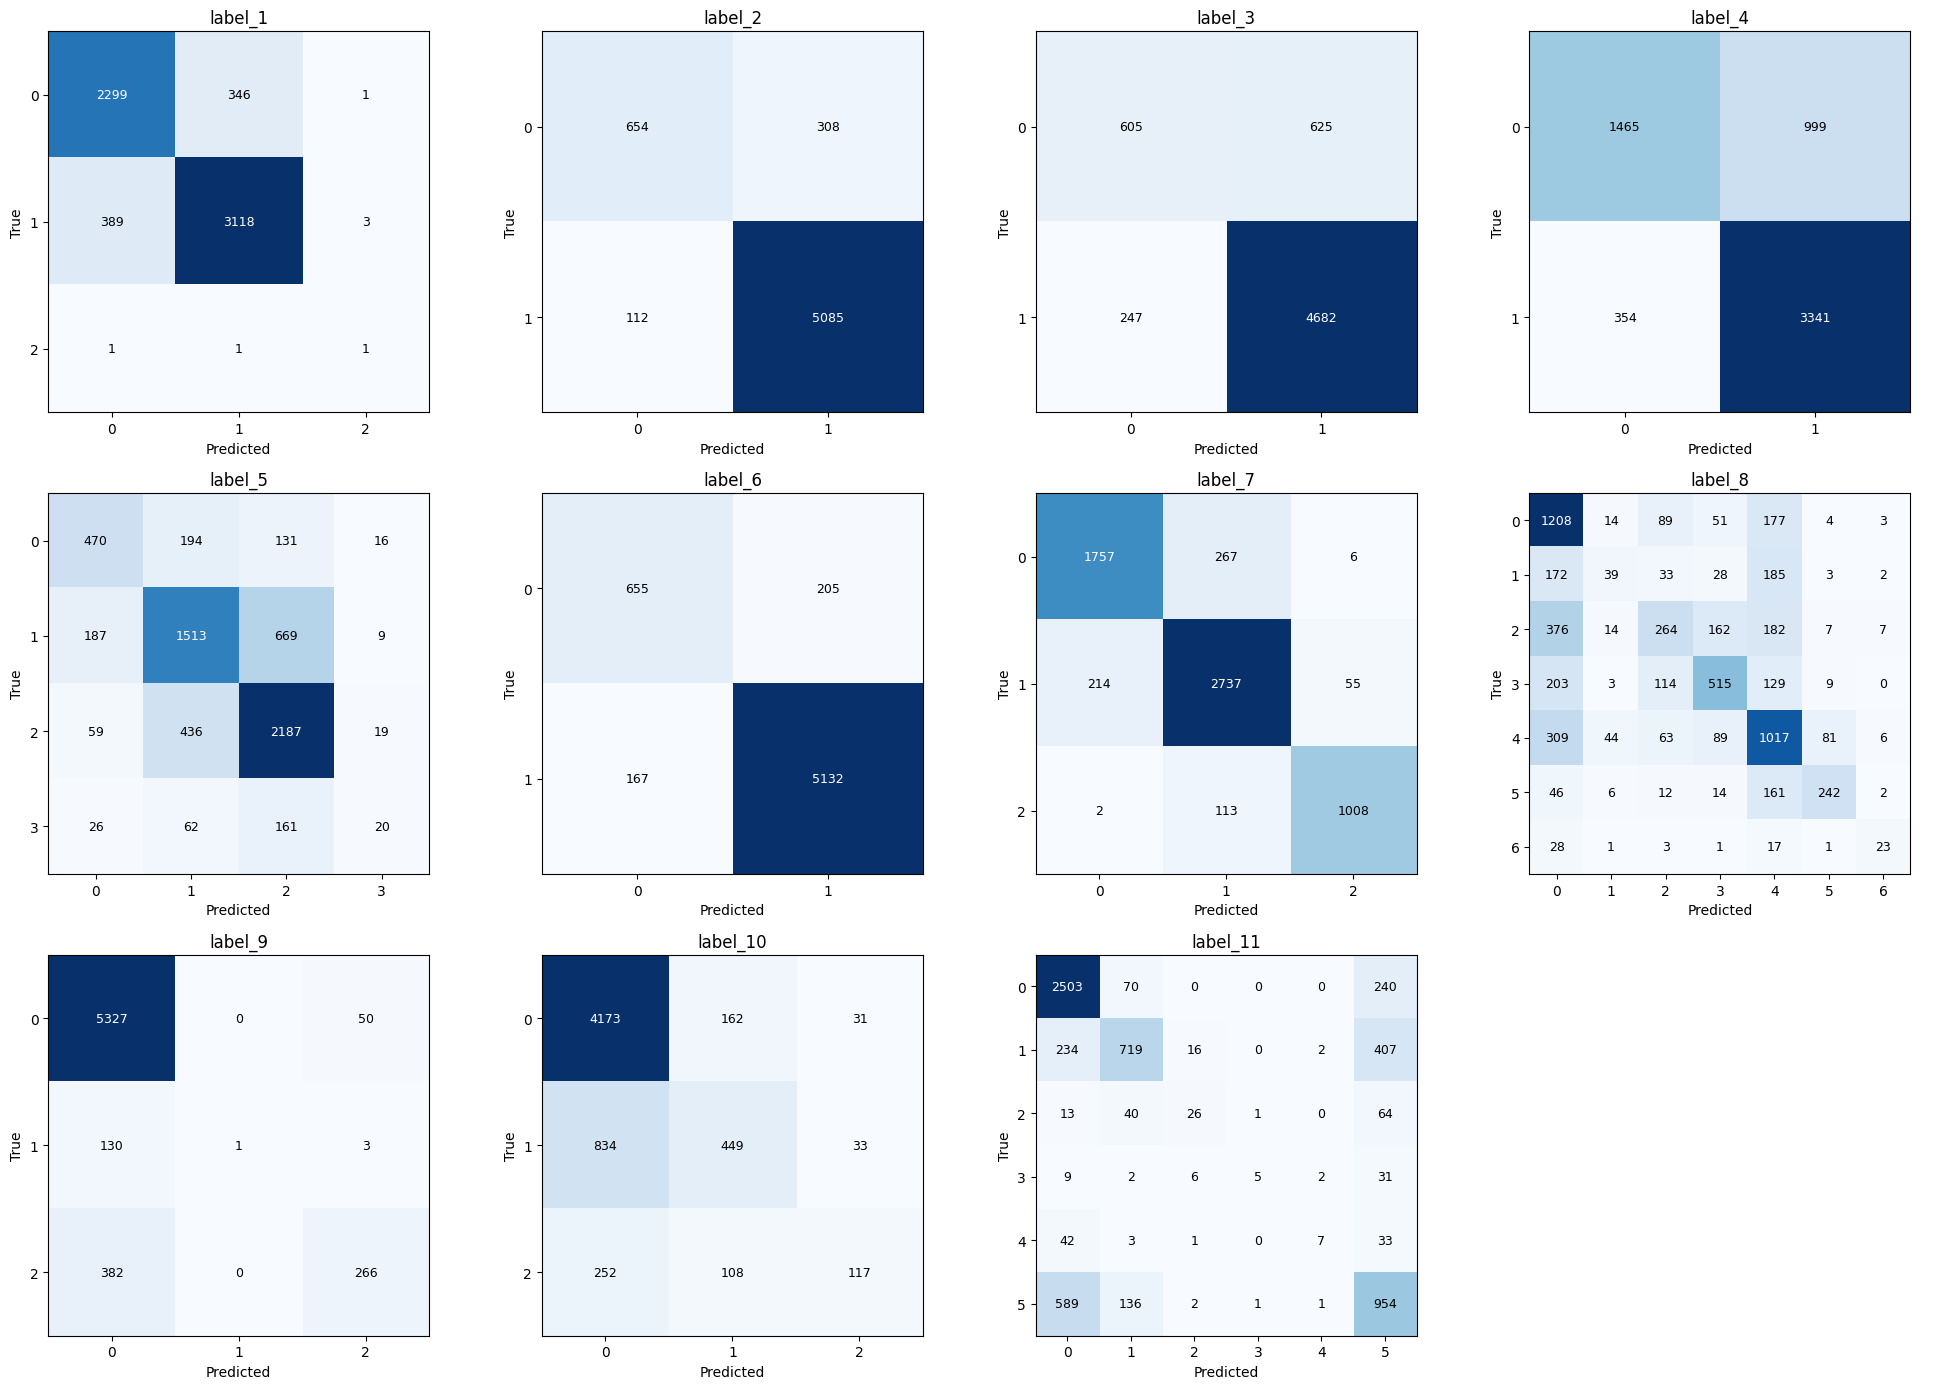

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

model.eval()
all_preds = [[] for _ in range(11)]
all_trues = [[] for _ in range(11)]

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            outputs = model(imgs)
        for i in range(11):
            all_preds[i].append(outputs[i].argmax(1).cpu().numpy())
            all_trues[i].append(labels[:, i].numpy())

all_preds = [np.concatenate(p) for p in all_preds]
all_trues = [np.concatenate(t) for t in all_trues]

for i in range(11):
    acc = (all_preds[i] == all_trues[i]).mean()
    print(f"label_{i+1:<3}  acc = {acc:.3f}")

mean_acc = np.mean([(all_preds[i] == all_trues[i]).mean() for i in range(11)])
print(f"\nMean acc = {mean_acc:.3f}")

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i in range(11):
    ax = axes[i]
    n_classes = num_classes_per_head[i]
    cm = confusion_matrix(all_trues[i], all_preds[i], labels=list(range(n_classes)))

    ax.imshow(cm, cmap='Blues')
    ax.set_title(f'label_{i+1}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))

    for r in range(n_classes):
        for c in range(n_classes):
            ax.text(c, r, cm[r, c], ha='center', va='center', fontsize=9,
                    color='white' if cm[r, c] > cm.max() / 2 else 'black')

axes[11].axis('off')
plt.tight_layout()
plt.show()